# Single-molecule two-colour TIRF: acceptor binding kinetics from time traces

**Purpose.** Take iSMS-exported donor/acceptor time traces (`Dem-Dexc`, `Aem-Dexc`, one `.txt`
per molecule) and

1. detect **photobleaching** and **photoblinking** and exclude those frames,
2. correct for **donor leakage** and **gamma** (fall back to 0.09 / 0.7 if the data cannot support an estimate),
3. **normalise** each trace by its mean total fluorescence,
4. fit a **5-state HMM globally**, then re-fit every trace starting from the global parameters,
5. call the acceptor **bound** in states whose FRET is above background,
6. fit the **bound dwell-time** distribution with 1- and 2-component exponential (rate) models,
7. histogram the FRET of bound frames and fit a **Gaussian mixture**.

Everything runs on a laptop CPU in well under a minute per few hundred traces; the reusable logic is in
`fretlib.py` (tested with `pytest`). Only donor excitation is available (no ALEX), so see the notes at
the end for what that implies.

## 1. Imports

In [1]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import fretlib as F

## 2. Parameters
Edit here (or override with `papermill -p NAME value`).

In [2]:
DATA_DIR = "data/example"          # folder with Traces_*_pair<N>.txt files
FILE_GLOB = "*.txt"
OUTPUT_DIR = "results"
FRAME_TIME_S = 1.0                 # seconds per frame -> rates are in 1/s (1.0 = rates per frame)
SEED = 0

# photobleaching / photoblinking detection
DARK_FRACTION = 0.4                # dark if total < dark + this * (bright - dark); 0.4 keeps high-FRET frames
MIN_DROP = 0.5                     # dark cluster must be < (1 - MIN_DROP) * bright cluster to count
MIN_BRIGHT_RUN = 3                 # bright runs shorter than this inside dark periods are spikes -> dark
MIN_BLEACH_FRAMES = 5              # terminal dark run needed to call photobleaching
PAD_FRAMES = 1                     # extra frames dropped on each side of a dark period
MIN_SNR = 8.0                      # bright level must exceed this x frame-to-frame noise
MIN_VALID_FRAMES = 50              # traces with fewer usable frames are rejected
MIN_SEGMENT_FRAMES = 5             # shortest contiguous stretch given to the HMM

# leakage / gamma (estimated from the data when enough events exist, otherwise defaults)
DEFAULT_LEAKAGE = 0.09
DEFAULT_GAMMA = 0.7
MIN_LEAK_TRACES = 3                # traces (each with >= 100 acceptor-free frames) needed for leakage
MIN_GAMMA_EVENTS = 5               # binding events needed for gamma
EVENT_SIGMA = 3.0                  # donor-down & acceptor-up threshold (robust sigmas)

# HMM
N_STATES = 5
GLOBAL_MAX_ITER = 200
INDIVIDUAL_MAX_ITER = 50
PRIOR_STRENGTH = 10.0              # weak pull of individual fits towards global parameters (pseudo-frames); 0 = off
BOUND_MARGIN = 0.10                # a state is "bound" if its FRET > FRET of lowest state + this

# dwell times / GMM
N_BOOT = 200                       # bootstrap resamples for dwell-model confidence intervals (0 = skip)
GMM_MAX_COMPONENTS = 4
GMM_N_COMPONENTS = None            # None = choose by BIC
N_EXAMPLE_TRACES = 5               # traces drawn in the example figure

In [3]:
out = Path(OUTPUT_DIR)
(out / "figures").mkdir(parents=True, exist_ok=True)
np.random.seed(SEED)

# Colour-vision-safe palette (blue / orange / aqua / violet); text stays neutral.
C_D, C_A, C_OK, C_X, C_BOUND = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#1baf7a"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold",
                     "legend.frameon": False})

## 3. Load traces

In [4]:
traces = F.load_traces(DATA_DIR, FILE_GLOB)
print(f"{len(traces)} traces, {sum(t.n_frames for t in traces)} frames in total")
pd.DataFrame([dict(pair=t.pair, movie=t.movie, n_frames=t.n_frames) for t in traces]).head(10)

5 traces, 6000 frames in total


,pair,movie,n_frames
0,19,Ch_3_1_001.tif,1200
1,86,Ch_3_1_001.tif,1200
2,87,Ch_3_1_001.tif,1200
3,94,Ch_3_1_001.tif,1200
4,123,Ch_3_1_001.tif,1200


## 4. Photobleaching and photoblinking

Detection acts on the **total intensity** `D + A`: donor loss on acceptor binding is compensated by
acceptor gain, so the total stays high during FRET but collapses to background when the dye is dark.

1. 1-D 2-means splits the total into a bright and a dark cluster; nothing is flagged unless the clusters are
   clearly separated (dark < 50 % of bright, bright > 8x noise), so traces that never bleach are untouched.
2. Frames below `dark + 0.4 (bright - dark)` are dark; short bright spikes inside dark periods are re-assigned to dark.
3. The dark run that reaches the end of the trace is **photobleaching**; any earlier dark run is a **blink**.
4. Dark frames are padded by one frame to remove partly-averaged transition frames.

All flagged frames are excluded. The HMM is fitted on contiguous stretches only and never bridges a gap.

In [5]:
pps = [F.detect_photophysics(t.D, t.A, dark_fraction=DARK_FRACTION, min_drop=MIN_DROP,
                             min_bright_len=MIN_BRIGHT_RUN, min_bleach_len=MIN_BLEACH_FRAMES,
                             pad=PAD_FRAMES, min_snr=MIN_SNR) for t in traces]
accepted = [p.status != "no_signal" and p.valid.sum() >= MIN_VALID_FRAMES for p in pps]

qc = pd.DataFrame([dict(
    pair=t.pair, status=p.status, accepted=ok, n_frames=t.n_frames, n_valid=int(p.valid.sum()),
    bleach_frame=p.bleach_frame, n_blinks=len(p.blinks),
    blink_frames=int(sum(e - s for s, e in p.blinks)), bright_level=p.bright_level, noise=p.noise)
    for t, p, ok in zip(traces, pps, accepted)])
print(f"accepted {sum(accepted)} / {len(traces)} traces")
qc.round(1)

accepted 5 / 5 traces


,pair,status,accepted,n_frames,n_valid,bleach_frame,n_blinks,blink_frames,bright_level,noise
0,19,ok,True,1200,808,809,0,0,65314.3,3028.7
1,86,ok,True,1200,750,751,0,0,53034.7,2572.7
2,87,ok,True,1200,281,282,0,0,52310.4,2109.3
3,94,ok,True,1200,490,491,0,0,51803.3,2271.8
4,123,ok,True,1200,281,282,0,0,52097.6,2228.8


In [6]:
traces_ok = [t for t, ok in zip(traces, accepted) if ok]
pps_ok = [p for p, ok in zip(pps, accepted) if ok]
if not traces_ok:
    raise RuntimeError("No trace passed quality control - check DATA_DIR and the detection parameters.")

## 5. Donor leakage and gamma

* **Binding events** are found model-free: frames where the donor falls and the acceptor rises together
  (> 3 robust sigma each) relative to a rolling median.
* **Leakage** `alpha`: with no acceptor bound, the acceptor channel contains only donor bleed-through,
  so `alpha = mean(A) / mean(D)` over event-free frames. One value per trace, median over traces.
* **Gamma**: at an event the donor loss `x = -dD` and the leakage-corrected acceptor gain
  `y = dA - alpha dD` are related by `y = gamma x` (conserved total). Gamma is the slope through the
  origin over all event frames; a bootstrap over events gives the CI.

If there are too few traces/events (or the estimate is implausible), the defaults (0.09 / 0.7) are used.

In [7]:
events = [F.find_fret_events(t.D, t.A, p.valid, n_sigma=EVENT_SIGMA) for t, p in zip(traces_ok, pps_ok)]
leak = F.estimate_leakage(traces_ok, [p.valid for p in pps_ok], events, min_traces=MIN_LEAK_TRACES,
                          default=DEFAULT_LEAKAGE)
ALPHA = leak["value"]
gam = F.estimate_gamma(traces_ok, events, ALPHA, min_events=MIN_GAMMA_EVENTS, default=DEFAULT_GAMMA, seed=SEED)
GAMMA = gam["value"]

leak_src = f"estimated from {leak['n_traces']} traces" if leak["estimated"] else "DEFAULT - not enough data"
gam_src = (f"estimated from {gam['n_events']} events, 95% CI [{gam['ci'][0]:.2f}, {gam['ci'][1]:.2f}]"
           if gam["estimated"] else f"DEFAULT - only {gam['n_events']} events")
print(f"leakage alpha = {ALPHA:.4f}  ({leak_src})")
print(f"gamma         = {GAMMA:.3f}  ({gam_src})")

leakage alpha = 0.0857  (estimated from 5 traces)
gamma         = 0.647  (estimated from 6 events, 95% CI [0.60, 0.74])


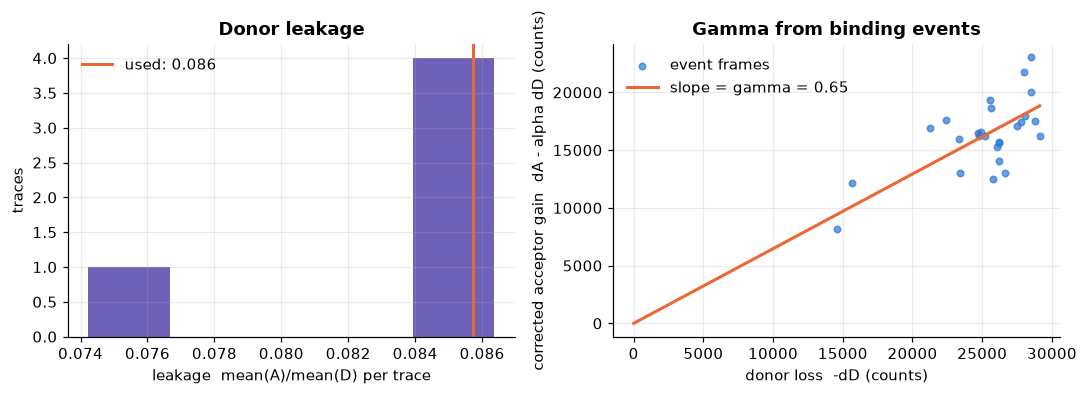

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
if len(leak["per_trace"]):
    ax[0].hist(leak["per_trace"], bins=min(30, max(5, len(leak["per_trace"]) // 2)), color=C_X, alpha=0.8)
ax[0].axvline(ALPHA, color=C_A, lw=2, label=f"used: {ALPHA:.3f}")
ax[0].set(xlabel="leakage  mean(A)/mean(D) per trace", ylabel="traces", title="Donor leakage")
ax[0].legend()
if len(gam["x"]):
    ax[1].scatter(gam["x"], gam["y"], s=18, color=C_D, alpha=0.7, label="event frames")
xx = np.linspace(0, max(gam["x"].max() if len(gam["x"]) else 1, 1), 50)
ax[1].plot(xx, GAMMA * xx, color=C_A, lw=2, label=f"slope = gamma = {GAMMA:.2f}")
ax[1].set(xlabel="donor loss  -dD (counts)", ylabel="corrected acceptor gain  dA - alpha dD (counts)", title="Gamma from binding events")
ax[1].legend()
fig.tight_layout()
fig.savefig(out / "figures" / "leakage_gamma.png", bbox_inches="tight")
plt.show()

## 6. Correct and normalise

`A_corr = A - alpha D`, `D_corr = gamma D`; both divided by the trace's **mean total**
`<A_corr + gamma D>` over usable frames. FRET of any frame/state is `An / (An + Dn)`, which equals
`A_corr / (A_corr + gamma D)`. The HMM observes the 2-D vector `(Dn, An)`, so it uses intensity as well as
ratio information and keeps the anti-correlation between channels.

In [9]:
norm = []     # one dict per accepted trace
for t, p in zip(traces_ok, pps_ok):
    Dn, An, mt = F.correct_and_normalize(t.D, t.A, p.valid, ALPHA, GAMMA)
    segs = F.split_segments(p.valid, MIN_SEGMENT_FRAMES)
    norm.append(dict(trace=t, pp=p, Dn=Dn, An=An, mean_total=mt, segs=segs))

X_all = np.vstack([np.column_stack([n["Dn"][s:e], n["An"][s:e]]) for n in norm for s, e in n["segs"]])
lengths_all = [e - s for n in norm for s, e in n["segs"]]
print(f"{len(lengths_all)} contiguous segments, {len(X_all)} frames go into the global HMM")

5 contiguous segments, 2610 frames go into the global HMM


## 7. Global 5-state HMM

Full-covariance 2-D Gaussian emissions on `(Dn, An)`, all segments of all traces fitted together.
Starting values: state 0 = donor-only cloud, the other states at quantiles of the FRET distribution of the
remaining frames (binding is rare, so plain k-means would place every centre inside the donor-only cloud).
States are sorted by FRET. A state is **acceptor-bound** if its FRET exceeds the FRET of the lowest
(donor-only / background) state by `BOUND_MARGIN`.

In [10]:
g = F.fit_global_hmm(X_all, lengths_all, N_STATES, n_iter=GLOBAL_MAX_ITER)
E_BG = float(F.state_fret(g.means_)[0])
E_THR = E_BG + BOUND_MARGIN
states_global = F.state_table(g, E_THR)
print(f"converged: {g.converged_}   log-likelihood: {g.loglik_:.1f}")
print(f"background FRET = {E_BG:.3f}  ->  bound if FRET > {E_THR:.3f}")
states_global.round(3)

converged: True   log-likelihood: 7068.1
background FRET = -0.012  ->  bound if FRET > 0.088


,state,Dn,An,FRET,sd_Dn,sd_An,self_transition,bound
0,0,0.972,-0.012,-0.012,0.054,0.063,0.979,False
1,1,1.054,0.003,0.003,0.059,0.068,0.973,False
2,2,0.838,0.214,0.204,0.138,0.021,0.000,True
3,3,0.527,0.496,0.485,0.100,0.129,0.303,True
4,4,0.526,0.528,0.501,0.031,0.060,0.943,True


In [11]:
pd.DataFrame(g.transmat_, columns=[f"to {i}" for i in range(N_STATES)],
             index=[f"from {i}" for i in range(N_STATES)]).round(4)

,to 0,to 1,to 2,to 3,to 4
from 0,0.9794,0.0161,0.0037,0.0009,0.0000
from 1,0.0242,0.9732,0.0000,0.0026,0.0000
from 2,0.8542,0.0000,0.0000,0.1458,0.0000
from 3,0.2927,0.1246,0.1383,0.3032,0.1412
from 4,0.0570,0.0000,0.0000,0.0000,0.9430


## 8. Individual HMM fits

Each trace is re-fitted from the global parameters (all state means, covariances, transition and start
probabilities). A weak MAP prior (`PRIOR_STRENGTH` pseudo-frames) keeps states that never occur in a trace from
drifting onto noise; if a fit fails the global model is used for that trace and it is flagged. The same absolute
FRET threshold is applied to every trace's fitted states, then Viterbi paths give the bound/unbound call.

In [12]:
frame_tables, bound_paths, trace_rows, indiv_states = [], [], [], []
for n in norm:
    t, p = n["trace"], n["pp"]
    Xs = [np.column_stack([n["Dn"][s:e], n["An"][s:e]]) for s, e in n["segs"]]
    if not Xs:
        trace_rows.append(dict(pair=t.pair, fit_ok=False, n_fit_frames=0))
        continue
    L = [len(x) for x in Xs]
    model, ok = F.fit_individual_hmm(np.vstack(Xs), L, g, prior_strength=PRIOR_STRENGTH,
                                     n_iter=INDIVIDUAL_MAX_ITER)
    sE = F.state_fret(model.means_)
    bound_state = sE > E_THR
    paths = F.viterbi_segments(model, np.vstack(Xs), L)
    pos = 0
    for (s, e), x in zip(n["segs"], Xs):
        st = paths[pos:pos + len(x)]
        pos += len(x)
        b = bound_state[st]
        bound_paths.append((f"pair{t.pair}", s, b))
        frame_tables.append(pd.DataFrame(dict(
            pair=t.pair, frame=np.arange(s, e), Dn=x[:, 0], An=x[:, 1], FRET=F.frame_fret(x[:, 0], x[:, 1]),
            state=st, state_FRET=sE[st], bound=b)))
    for k in range(N_STATES):
        indiv_states.append(dict(pair=t.pair, state=k, FRET=sE[k], occupancy=float(np.mean(np.concatenate(
            [paths[sum(L[:i]):sum(L[:i + 1])] for i in range(len(L))]) == k))))
    trace_rows.append(dict(pair=t.pair, fit_ok=ok, n_fit_frames=int(sum(L))))

frames = pd.concat(frame_tables, ignore_index=True)
dwells = F.extract_dwells(bound_paths)

summary = qc[qc.accepted].reset_index(drop=True).merge(pd.DataFrame(trace_rows), on="pair", how="left")
summary["mean_total_counts"] = [n["mean_total"] for n in norm]
per_trace = frames.groupby("pair").agg(bound_frames=("bound", "sum"), frames_fit=("bound", "size"))
summary = summary.merge(per_trace, on="pair", how="left")
summary["n_bound_events"] = summary.pair.map(dwells[dwells.bound].groupby(dwells.trace.str.replace("pair", "").astype(int)).size()).fillna(0).astype(int)
summary["bound_fraction"] = summary.bound_frames / summary.frames_fit
print(f"individual fits ok: {int(summary.fit_ok.sum())} / {len(summary)}")
summary.round(3)

individual fits ok: 5 / 5


,pair,status,accepted,n_frames,n_valid,bleach_frame,n_blinks,blink_frames,bright_level,noise,fit_ok,n_fit_frames,mean_total_counts,bound_frames,frames_fit,n_bound_events,bound_fraction
0,19,ok,True,1200,808,809,0,0,65314.265,3028.702,True,808,38640.954,1,808,1,0.001
1,86,ok,True,1200,750,751,0,0,53034.730,2572.667,True,750,31690.900,6,750,5,0.008
2,87,ok,True,1200,281,282,0,0,52310.382,2109.293,True,281,31388.897,2,281,1,0.007
3,94,ok,True,1200,490,491,0,0,51803.304,2271.789,True,490,31287.555,21,490,3,0.043
4,123,ok,True,1200,281,282,0,0,52097.636,2228.806,True,281,30996.368,3,281,1,0.011


### Example traces
Top: raw donor/acceptor with excluded frames shaded (grey = blink, red = after photobleaching).
Bottom: corrected, normalised signals with frames the HMM calls **acceptor-bound** shaded green.

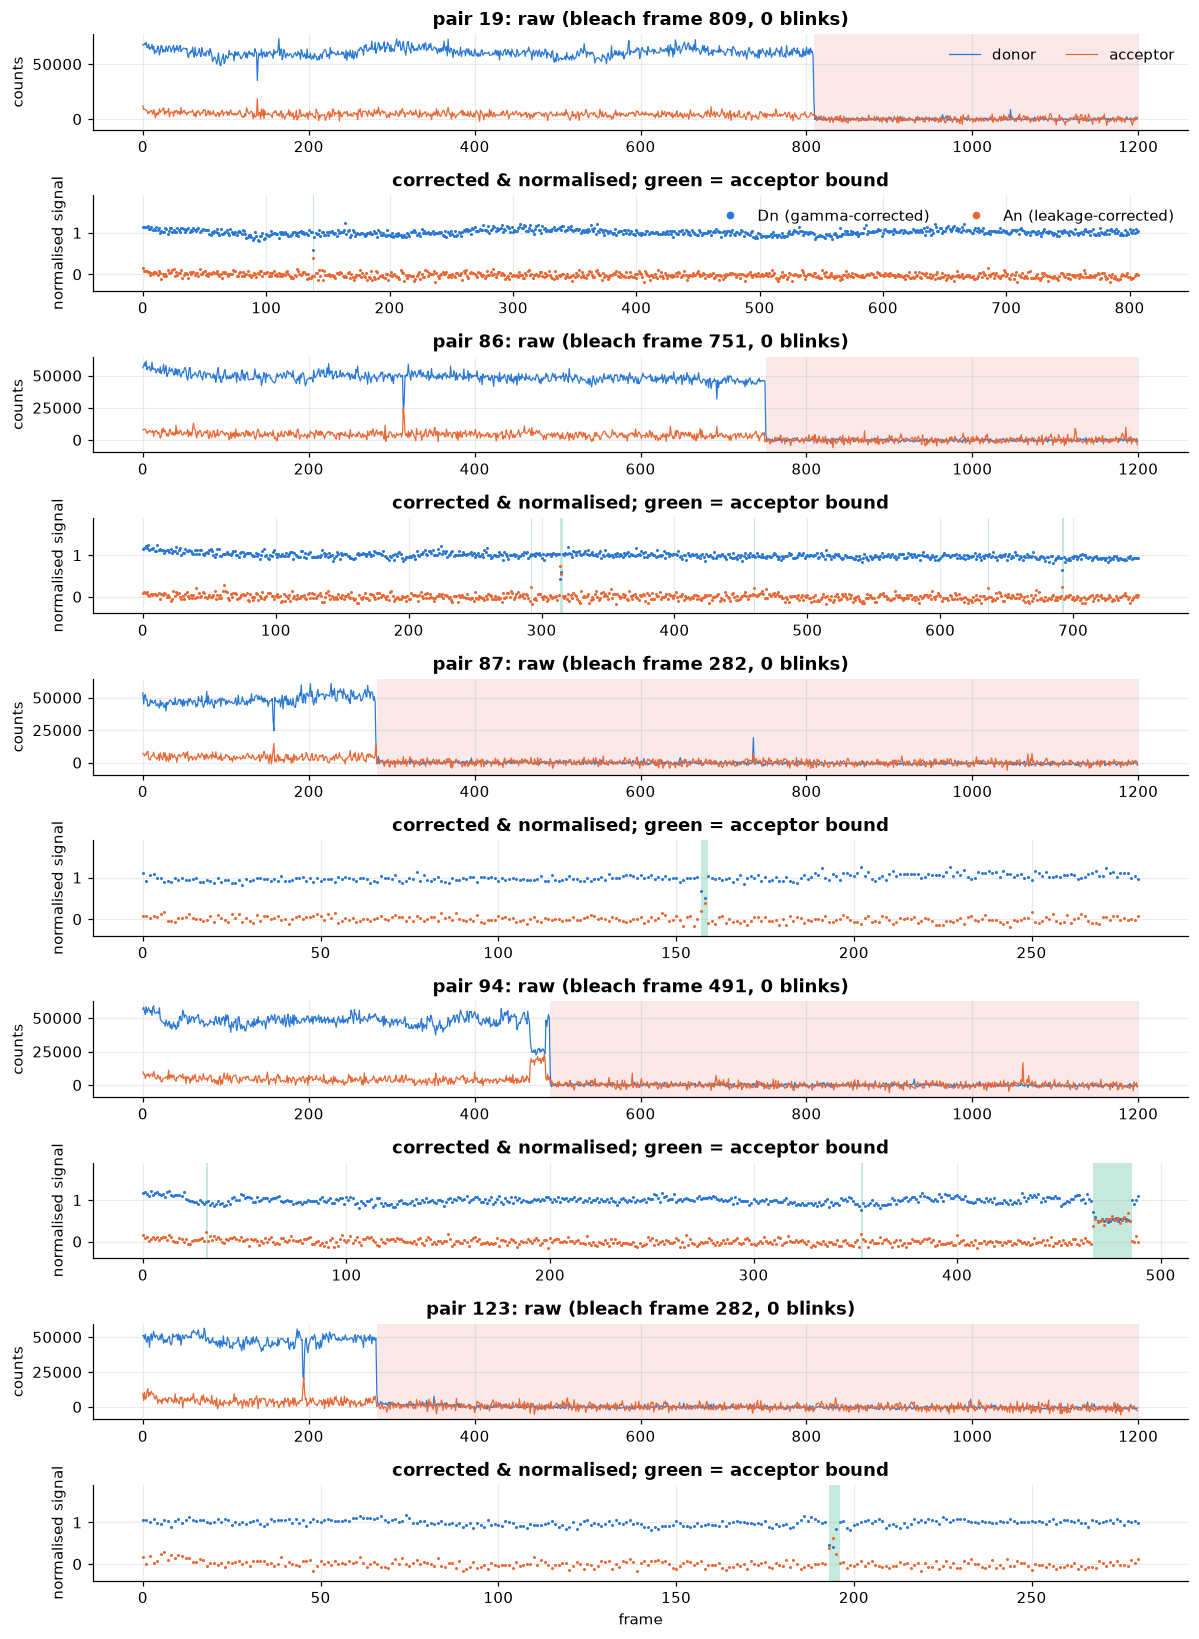

In [13]:
sel = norm[:N_EXAMPLE_TRACES]
fig, axes = plt.subplots(2 * len(sel), 1, figsize=(11, 3.0 * len(sel)), sharex=False)
axes = np.atleast_1d(axes)
for i, n in enumerate(sel):
    t, p = n["trace"], n["pp"]
    a0, a1 = axes[2 * i], axes[2 * i + 1]
    fr = np.arange(t.n_frames)
    a0.plot(fr, t.D, color=C_D, lw=0.8, label="donor")
    a0.plot(fr, t.A, color=C_A, lw=0.8, label="acceptor")
    for s, e in p.blinks:
        a0.axvspan(s, e, color="0.6", alpha=0.35, lw=0)
    if p.bleach_frame is not None:
        a0.axvspan(p.bleach_frame, t.n_frames, color="#e34948", alpha=0.12, lw=0)
    a0.set(ylabel="counts", title=f"pair {t.pair}: raw (bleach frame {p.bleach_frame}, {len(p.blinks)} blinks)")
    a1.plot(fr[p.valid], n["Dn"][p.valid], ".", ms=2, color=C_D, label="Dn (gamma-corrected)")
    a1.plot(fr[p.valid], n["An"][p.valid], ".", ms=2, color=C_A, label="An (leakage-corrected)")
    ft = frames[frames.pair == t.pair]
    for s, e in F.find_runs(np.isin(fr, ft.frame[ft.bound])):
        a1.axvspan(s, e, color=C_BOUND, alpha=0.25, lw=0)
    a1.set(ylabel="normalised signal", ylim=(-0.4, 1.9), title="corrected & normalised; green = acceptor bound")
    if i == 0:
        a0.legend(loc="upper right", ncol=2)
        a1.legend(loc="upper right", ncol=2, markerscale=4)
axes[-1].set_xlabel("frame")
fig.tight_layout()
fig.savefig(out / "figures" / "example_traces.png", bbox_inches="tight")
plt.show()

## 9. Acceptor dwell times: 1- vs 2-component rate models

A *bound dwell* is an uninterrupted Viterbi run in a bound state. Dwells that touch the end of a usable
segment are **right-censored** (the acceptor was still bound when bleaching, a blink or the end of the movie
cut the observation) and enter the likelihood through the survival function; dwells that begin at the start of
a segment are left-censored and dropped from the bound-dwell fit. Times are quantised to frames; the likelihood
uses `P(n frames) = S((n-1)dt) - S(n dt)` with `S(t) = sum_i w_i exp(-k_i t)`.
Models are compared with AIC/BIC (lower is better). The **unbound** dwell fit (time to binding) is shown too;
there left-censored dwells are kept as censored observations (memoryless approximation) because most traces
contain no binding event at all.

In [14]:
def dwell_fits(kind):
    d = dwells[dwells.bound == (kind == "bound")]
    if kind == "bound":
        d = d[~d.left_censored]
        cens = d.right_censored.to_numpy()
    else:
        cens = (d.right_censored | d.left_censored).to_numpy()
    n = d.n_frames.to_numpy()
    res = {}
    if (~cens).sum() < 2:
        return d, n, cens, res
    for nc in (1, 2):
        r = F.fit_dwell_model(n, cens, FRAME_TIME_S, nc, seed=SEED)
        if N_BOOT:
            bs = F.bootstrap_dwell_model(n, cens, FRAME_TIME_S, nc, n_boot=N_BOOT, seed=SEED)
            r["boot"] = bs
        res[nc] = r
    return d, n, cens, res


def fit_table(kind, res):
    rows = []
    for nc, r in res.items():
        row = dict(dwell_type=kind, model=f"{nc}-component", n_dwells=r["n_dwells"], n_censored=r["n_censored"],
                   loglik=r["loglik"], AIC=r["aic"], BIC=r["bic"], mean_dwell_s=r["mean_dwell"])
        for i, (k, w) in enumerate(zip(r["rates"], r["weights"]), 1):
            row[f"k{i} (1/s)"], row[f"w{i}"] = k, w
            if "boot" in r and len(r["boot"]):
                lo, hi = np.percentile(r["boot"][f"k{i}"], [2.5, 97.5])
                row[f"k{i} 95% CI"] = f"[{lo:.3g}, {hi:.3g}]"
        rows.append(row)
    return pd.DataFrame(rows)


dwell_results = {kind: dwell_fits(kind) for kind in ("bound", "unbound")}
fit_tables = pd.concat([fit_table(k, v[3]) for k, v in dwell_results.items() if v[3]], ignore_index=True)
fit_tables

,dwell_type,model,n_dwells,n_censored,loglik,AIC,BIC,mean_dwell_s,k1 (1/s),w1,k1 95% CI,k2 (1/s),w2,k2 95% CI
0,bound,1-component,11,0,-21.004968,44.009935,44.407830,2.466304,4.054651e-01,1.000000,"[0.142, 1.87]",NaN,NaN,NaN
1,bound,2-component,11,0,-15.422200,36.844400,38.038086,2.406747,6.756645e-02,0.116413,"[0.0613, 1.55]",1.292154,0.883587,"[0.782, 10]"
2,unbound,1-component,16,10,-42.345385,86.690769,87.463358,427.331414,2.340104e-03,1.000000,"[0.000764, 0.00484]",NaN,NaN,NaN
3,unbound,2-component,16,10,-42.224224,90.448449,92.766215,522279.453523,3.880481e-07,0.202580,"[2.65e-07, 0.00481]",0.003449,0.797420,"[0.00116, 0.0327]"


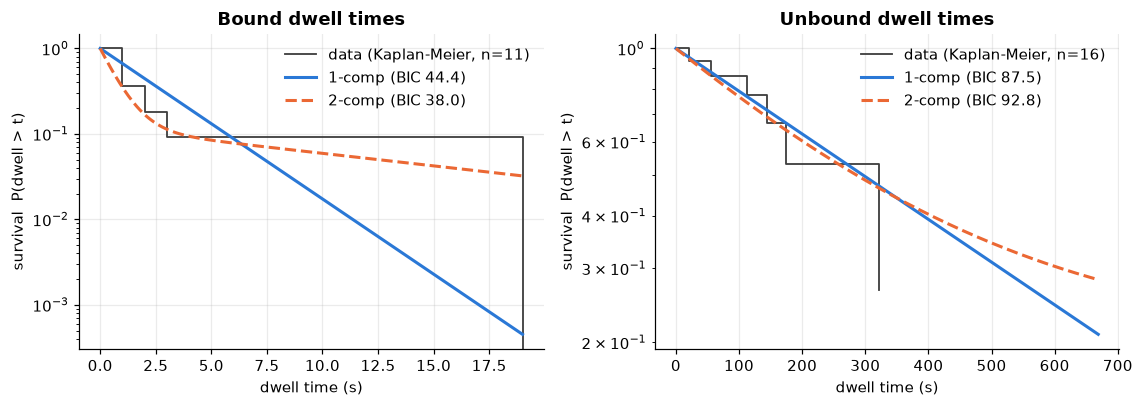

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for ax, kind in zip(axes, ("bound", "unbound")):
    d, n, cens, res = dwell_results[kind]
    ax.set(title=f"{kind.capitalize()} dwell times", xlabel="dwell time (s)", ylabel="survival  P(dwell > t)", yscale="log")
    if not res:
        ax.text(0.5, 0.5, "too few dwells to fit", transform=ax.transAxes, ha="center")
        continue
    tk, sk = F.kaplan_meier(n, cens, FRAME_TIME_S)
    ax.step(np.r_[0, tk], np.r_[1, sk], where="post", color="0.25", lw=1.2, label=f"data (Kaplan-Meier, n={len(n)})")
    tt = np.linspace(0, max(n.max() * FRAME_TIME_S, FRAME_TIME_S), 300)
    for nc, col in ((1, C_D), (2, C_A)):
        r = res[nc]
        ax.plot(tt, F.model_survival_curve(r, tt), color=col, lw=2, ls="-" if nc == 1 else "--",
                label=f"{nc}-comp (BIC {r['bic']:.1f})")
    ax.legend()
fig.tight_layout()
fig.savefig(out / "figures" / "dwell_times.png", bbox_inches="tight")
plt.show()

## 10. FRET histogram of acceptor-bound frames and Gaussian mixture

Frame-level FRET `An / (An + Dn)` of all frames the HMM calls bound, fitted with a 1-D Gaussian mixture
(components chosen by BIC unless `GMM_N_COMPONENTS` is set).

In [16]:
bound_E = frames.loc[frames.bound, "FRET"].to_numpy()
bound_E = bound_E[np.isfinite(bound_E)]
print(f"{len(bound_E)} bound frames from {frames[frames.bound].pair.nunique()} traces")
gmm, gmm_bic = F.fit_gmm_1d(bound_E, GMM_MAX_COMPONENTS, GMM_N_COMPONENTS, seed=SEED)
gmm_bic

33 bound frames from 5 traces


,n_components,BIC,AIC,loglik
0,1,-31.294536,-34.287551,19.143776
1,2,-51.386376,-58.868914,34.434457
2,3,-47.979254,-59.951314,37.975657


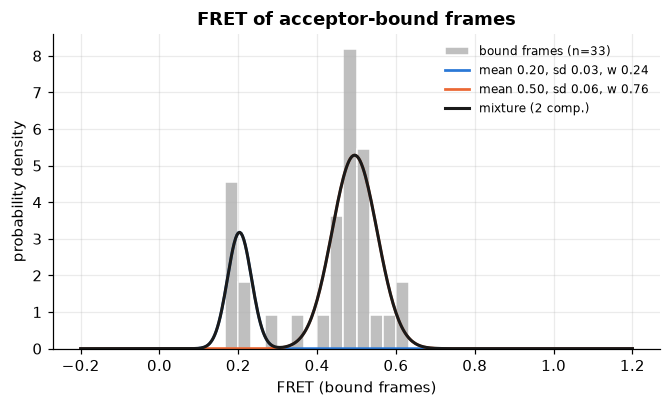

,mean,sd,weight
0,0.203,0.030,0.242
1,0.495,0.057,0.758


In [17]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
bins = np.linspace(-0.2, 1.2, 43)
ax.hist(bound_E, bins=bins, density=True, color="0.75", edgecolor="white", label=f"bound frames (n={len(bound_E)})")
gmm_table = pd.DataFrame()
if gmm is not None:
    xs = np.linspace(-0.2, 1.2, 400)
    order = np.argsort(gmm.means_.ravel())
    from scipy.stats import norm as _norm
    palette = [C_D, C_A, C_OK, C_X]
    for j, k in enumerate(order):
        mu, sd, w = gmm.means_[k, 0], np.sqrt(gmm.covariances_[k, 0, 0]), gmm.weights_[k]
        ax.plot(xs, w * _norm.pdf(xs, mu, sd), color=palette[j % 4], lw=1.8, label=f"mean {mu:.2f}, sd {sd:.2f}, w {w:.2f}")
    ax.plot(xs, np.exp(gmm.score_samples(xs[:, None])), color="0.1", lw=2, label=f"mixture ({gmm.n_components} comp.)")
    gmm_table = pd.DataFrame(dict(mean=gmm.means_.ravel()[order], sd=np.sqrt(gmm.covariances_[:, 0, 0])[order],
                                  weight=gmm.weights_[order]))
ax.set(xlabel="FRET (bound frames)", ylabel="probability density", title="FRET of acceptor-bound frames")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(out / "figures" / "bound_fret_gmm.png", bbox_inches="tight")
plt.show()
gmm_table.round(3)

## 11. Save results

In [18]:
summary.to_csv(out / "trace_summary.csv", index=False)
qc.to_csv(out / "photophysics_qc.csv", index=False)
states_global.to_csv(out / "hmm_global_states.csv", index=False)
pd.DataFrame(indiv_states).to_csv(out / "hmm_individual_states.csv", index=False)
dwells.to_csv(out / "dwells.csv", index=False)
fit_tables.to_csv(out / "dwell_model_fits.csv", index=False)
gmm_table.to_csv(out / "bound_fret_gmm.csv", index=False)
frames.to_csv(out / "frames.csv.gz", index=False)
with open(out / "parameters_used.json", "w") as fh:
    json.dump(dict(leakage=ALPHA, leakage_estimated=bool(leak["estimated"]), gamma=GAMMA,
                   gamma_estimated=bool(gam["estimated"]), gamma_ci=list(map(float, gam["ci"])),
                   n_binding_events_for_gamma=int(gam["n_events"]), background_fret=E_BG,
                   bound_fret_threshold=E_THR, frame_time_s=FRAME_TIME_S, n_traces=len(traces),
                   n_traces_accepted=len(traces_ok)), fh, indent=2)
print("saved to", out.resolve())
sorted(p.name for p in out.iterdir())

saved to /home/user/20261001-FRET-colocalization/results


['bound_fret_gmm.csv',
 'dwell_model_fits.csv',
 'dwells.csv',
 'figures',
 'frames.csv.gz',
 'hmm_global_states.csv',
 'hmm_individual_states.csv',
 'parameters_used.json',
 'photophysics_qc.csv',
 'trace_summary.csv']

## Notes and limitations

* **Donor excitation only.** Without direct acceptor excitation, *acceptor* photobleaching or blinking while bound is
  indistinguishable from dissociation, so it shortens the apparent bound dwell time (bound dwells are therefore lower
  bounds on residence time). Donor bleaching/blinking is caught from the collapse of the total signal.
* **Leakage** here also absorbs any direct acceptor excitation by the donor laser (same signature when only donor
  excitation is used). It is estimated from acceptor-free frames and assumes the background subtraction left no offset.
* **Gamma and leakage are global** (pooled over traces); with few traces/events the defaults 0.09 / 0.7 are used and
  the printout in section 5 says so. With the 5 example traces both are estimated (6 events), giving values close to
  the defaults.
* **Dwell times** are limited by the frame time; most example events last 1-3 frames, so rates close to
  `1/FRAME_TIME_S` are at the resolution limit. Set `FRAME_TIME_S` to the exposure time to get rates in 1/s.
* Few bound dwells make the 2-component model poorly determined; use the BIC, the bootstrap CIs, and the number of dwells
  reported before interpreting a second component.